# Order Book Simulation: Market Making Strategy Testing


In [14]:
import sys
sys.path.insert(0, '.')

from simulator import OrderBookSimulator
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Basic Simulation Run

Run a market maker with 20% inside the spread for 10,000 steps.

### Understanding the Output Metrics

| Metric | Meaning |
|--------|----------|
| **Steps** | Number of simulation time steps. Each step: price evolves → MM posts quotes → market orders arrive → some fills happen. More steps = longer trading session. |
| **Final P&L** (mark-to-market) | `cash + inventory × current_mid_price`. This is what the MM would have if they liquidated their remaining inventory at the current market price. It includes both realized gains (from completed round-trips) and unrealized gains/losses from open positions. |
| **Realized P&L** | Just the `cash` balance. Every buy subtracts `price × qty` from cash; every sell adds `price × qty`. This ignores the value of any inventory still held — it only counts money that has actually changed hands. |
| **Final inventory** | Net number of shares held. Positive = long (bought more than sold), negative = short (sold more than bought). An ideal market maker ends near zero — they want to earn the spread, not take directional bets. |
| **Buy fills** | How many times the MM's buy quote was hit by a market sell order. Each buy fill costs cash and adds to inventory. |
| **Sell fills** | How many times the MM's sell quote was lifted by a market buy order. Each sell fill adds cash and reduces inventory. |

**The gap between Final P&L and Realized P&L** = `inventory × current_mid_price`. If the MM holds 100 shares and mid is $100, that's $10,000 of unrealized exposure. A large gap means the MM is carrying significant inventory risk.

In [15]:
sim = OrderBookSimulator(
    initial_mid=100.0,
    base_spread_bps=5.0,
    volatility=0.02,
    fill_rate=0.15,
    adverse_selection_bps=0.5,
    seed=42,
)

results = sim.run(n_steps=10000, inside_pct=0.2, mm_qty=50)
df = sim.get_snapshot_dataframe()

print(f"Steps:          {len(df)}")
print(f"Final P&L:      ${sim.mark_to_market_pnl:.2f}")
print(f"Realized P&L:   ${sim.realized_pnl:.2f}")
print(f"Final inventory: {sim.inventory}")
print(f"Buy fills:      {sum(1 for f in sim.fills if f.side == 'buy')}")
print(f"Sell fills:     {sum(1 for f in sim.fills if f.side == 'sell')}")

Steps:          10000
Final P&L:      $1174.52
Realized P&L:   $-194747.50
Final inventory: 1950
Buy fills:      920
Sell fills:     881


## 2. Price Path and Spread

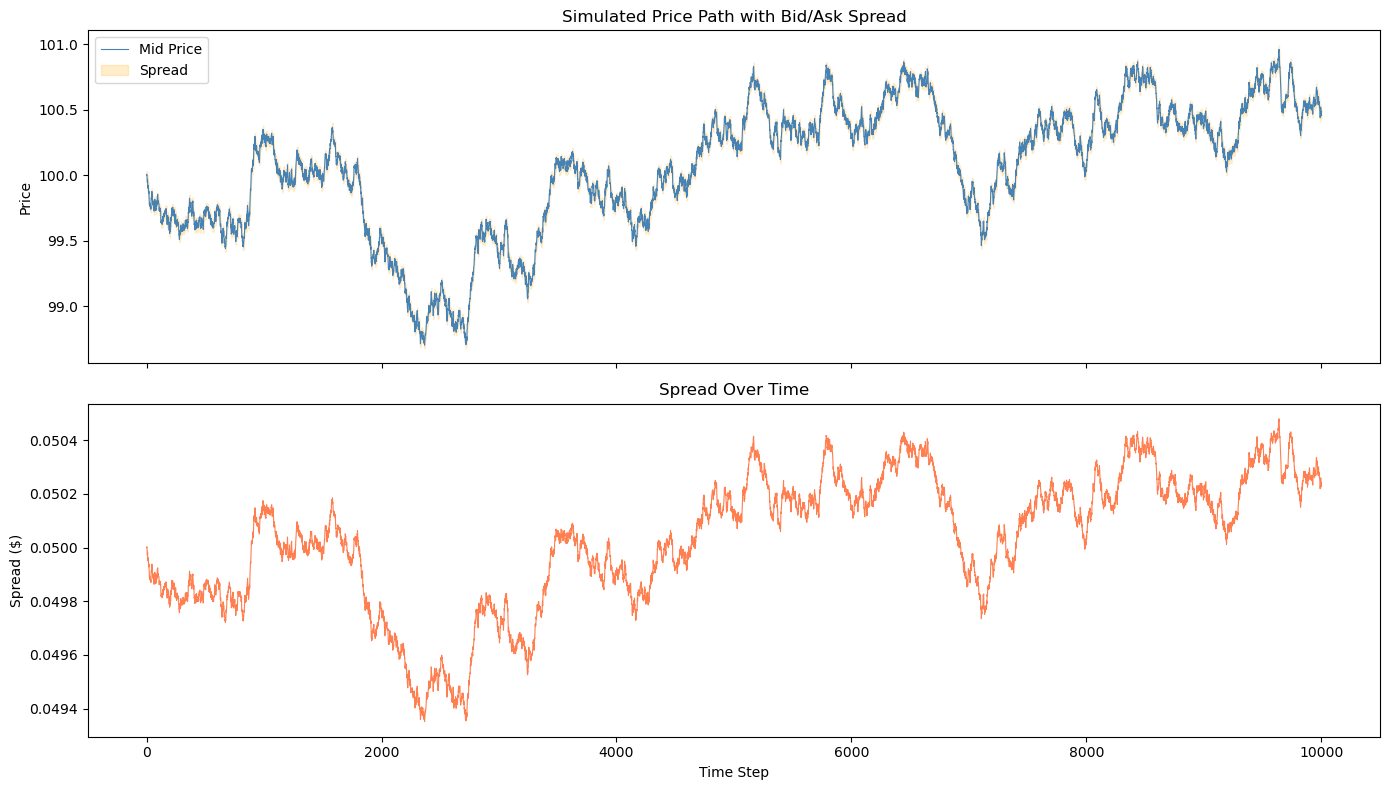

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(df['time'], df['mid_price'], linewidth=0.8, color='steelblue', label='Mid Price')
ax1.fill_between(df['time'], df['best_bid'], df['best_ask'], alpha=0.2, color='orange', label='Spread')
ax1.set_ylabel('Price')
ax1.set_title('Simulated Price Path with Bid/Ask Spread')
ax1.legend()

ax2.plot(df['time'], df['spread'], linewidth=0.8, color='coral')
ax2.set_ylabel('Spread ($)')
ax2.set_xlabel('Time Step')
ax2.set_title('Spread Over Time')

plt.tight_layout()
plt.show()

## 3. Inventory and Cash Over Time

A successful market maker should keep inventory near zero. Large inventory buildup means the MM is getting filled on one side more than the other.

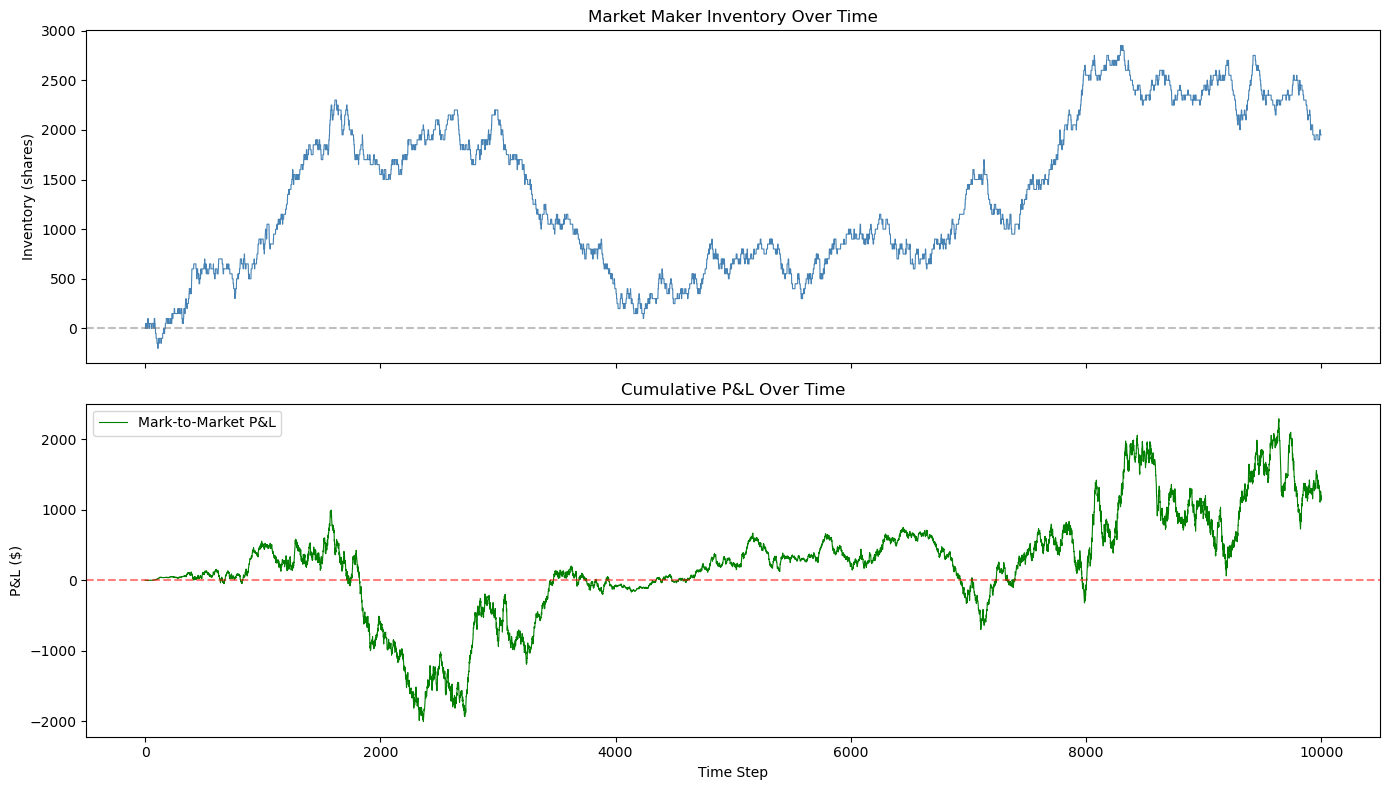

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(df['time'], df['inventory'], linewidth=0.8, color='steelblue')
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax1.set_ylabel('Inventory (shares)')
ax1.set_title('Market Maker Inventory Over Time')

ax2.plot(df['time'], df['pnl'], linewidth=0.8, color='green', label='Mark-to-Market P&L')
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)
ax2.set_ylabel('P&L ($)')
ax2.set_xlabel('Time Step')
ax2.set_title('Cumulative P&L Over Time')
ax2.legend()

plt.tight_layout()
plt.show()

## 4. Fill Analysis

In [18]:
fills_df = sim.get_fills_dataframe()

if len(fills_df) > 0:
    print(f"Total fills:     {len(fills_df)}")
    print(f"Buy fills:       {len(fills_df[fills_df['side'] == 'buy'])}")
    print(f"Sell fills:      {len(fills_df[fills_df['side'] == 'sell'])}")
    print(f"\nFill rate:       {len(fills_df) / len(df):.3f} fills/step")
    print(f"\nAvg slippage (buy):  ${fills_df[fills_df['side'] == 'buy']['slippage'].mean():.4f}")
    print(f"Avg slippage (sell): ${fills_df[fills_df['side'] == 'sell']['slippage'].mean():.4f}")
    print(f"\nRound-trip P&L:")
    buy_fills = fills_df[fills_df['side'] == 'buy']
    sell_fills = fills_df[fills_df['side'] == 'sell']
    total_buy_cost = (buy_fills['price'] * buy_fills['qty']).sum()
    total_sell_revenue = (sell_fills['price'] * sell_fills['qty']).sum()
    print(f"  Total buy cost:    ${total_buy_cost:.2f}")
    print(f"  Total sell revenue: ${total_sell_revenue:.2f}")
    print(f"  Net realized P&L:  ${total_sell_revenue - total_buy_cost:.2f}")
else:
    print("No fills recorded.")

Total fills:     1801
Buy fills:       920
Sell fills:      881

Fill rate:       0.180 fills/step

Avg slippage (buy):  $0.0025
Avg slippage (sell): $0.0024

Round-trip P&L:
  Total buy cost:    $4602674.84
  Total sell revenue: $4407927.33
  Net realized P&L:  $-194747.50


## 5. Comparing Strategies: Aggressive vs Passive

How does quote aggressiveness affect P&L, fill rate, and inventory?

Aggressive (10%): P&L=$2168.45, Fills=2298, Inventory=2300
Moderate (30%): P&L=$747.34, Fills=1420, Inventory=1500
Midpoint (50%): P&L=$526.19, Fills=765, Inventory=1550
Passive (70%): P&L=$21.35, Fills=262, Inventory=1100


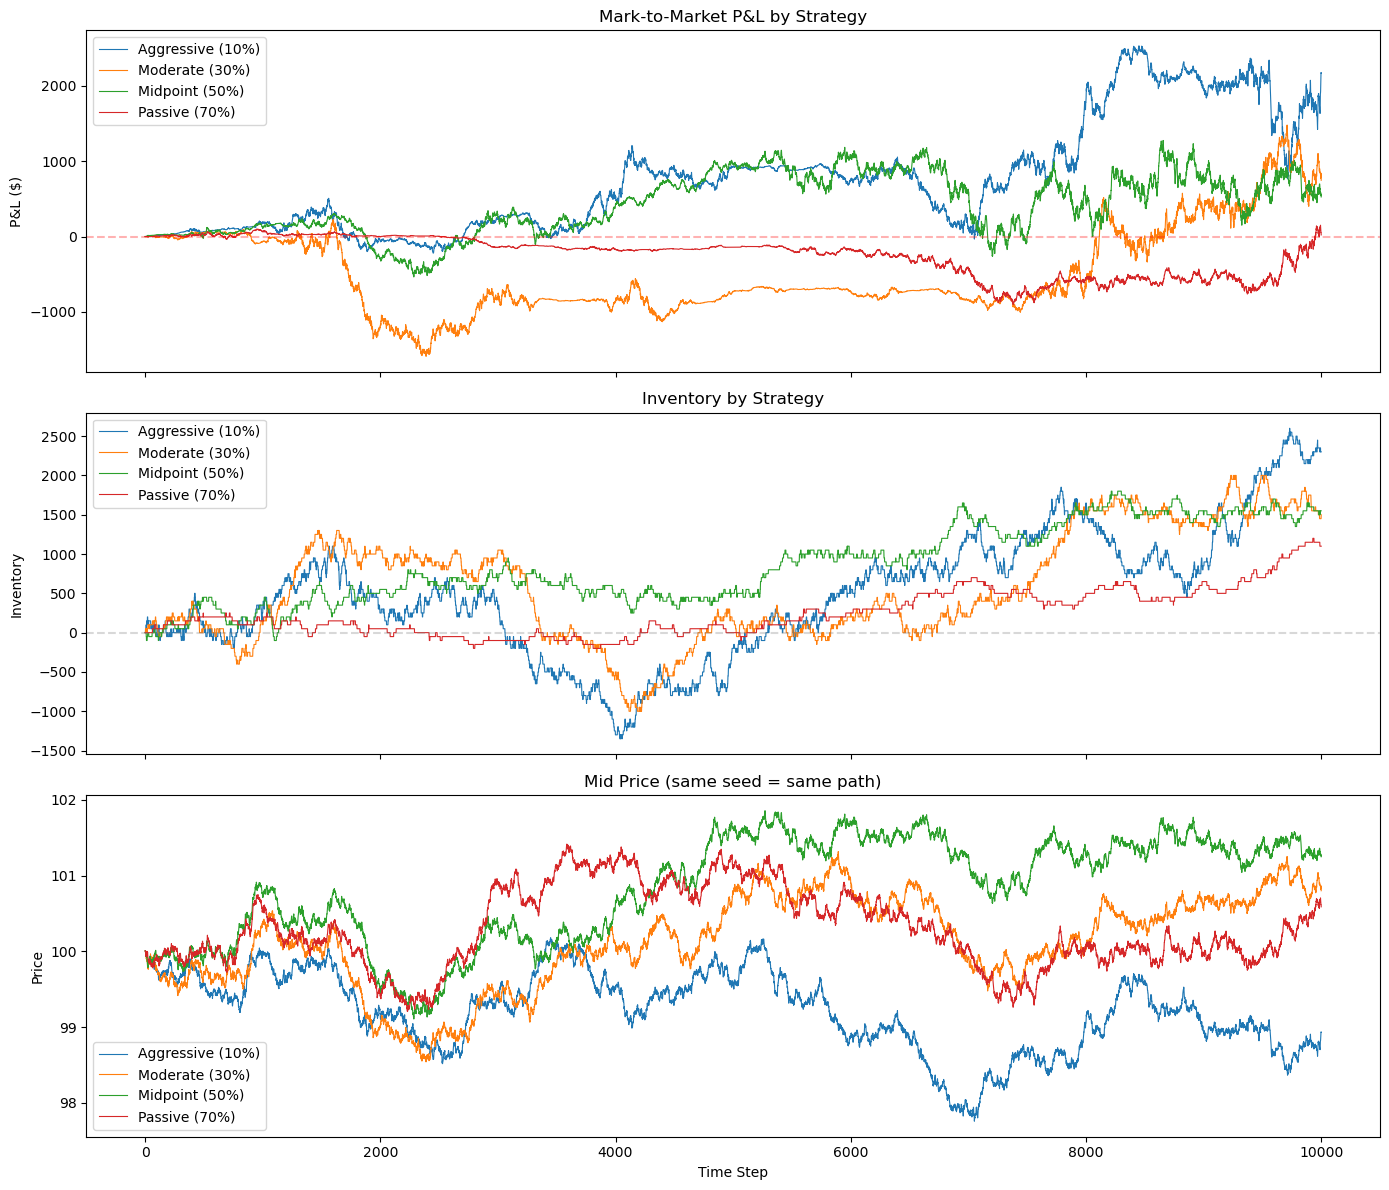

In [19]:
strategies = {
    'Aggressive (10%)': 0.1,
    'Moderate (30%)': 0.3,
    'Midpoint (50%)': 0.5,
    'Passive (70%)': 0.7,
}

N_STEPS = 10000

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
ax_pnl, ax_inv, ax_mid = axes

for name, inside_pct in strategies.items():
    sim = OrderBookSimulator(
        initial_mid=100.0,
        base_spread_bps=5.0,
        volatility=0.02,
        fill_rate=0.15,
        adverse_selection_bps=0.5,
        seed=42,
    )
    sim.run(n_steps=N_STEPS, inside_pct=inside_pct, mm_qty=50)
    df = sim.get_snapshot_dataframe()
    fills = sim.get_fills_dataframe()
    
    n_fills = len(fills) if len(fills) > 0 else 0
    print(f"{name}: P&L=${sim.mark_to_market_pnl:.2f}, "
          f"Fills={n_fills}, Inventory={sim.inventory}")
    
    ax_pnl.plot(df['time'], df['pnl'], linewidth=0.8, label=name)
    ax_inv.plot(df['time'], df['inventory'], linewidth=0.8, label=name)
    ax_mid.plot(df['time'], df['mid_price'], linewidth=0.8, label=name)

ax_pnl.axhline(0, color='red', linestyle='--', alpha=0.3)
ax_pnl.set_ylabel('P&L ($)')
ax_pnl.set_title('Mark-to-Market P&L by Strategy')
ax_pnl.legend()

ax_inv.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax_inv.set_ylabel('Inventory')
ax_inv.set_title('Inventory by Strategy')
ax_inv.legend()

ax_mid.set_ylabel('Price')
ax_mid.set_xlabel('Time Step')
ax_mid.set_title('Mid Price (same seed = same path)')
ax_mid.legend()

plt.tight_layout()
plt.show()

## 6. Profit vs Fill Probability Tradeoff

There's a fundamental tradeoff in market making:
- **Aggressive quotes** (low inside_pct, closer to edge): More fills (queue priority), less profit per fill, more adverse selection
- **Passive quotes** (high inside_pct, closer to mid): Fewer fills (deeper in book), more profit per fill, less adverse selection

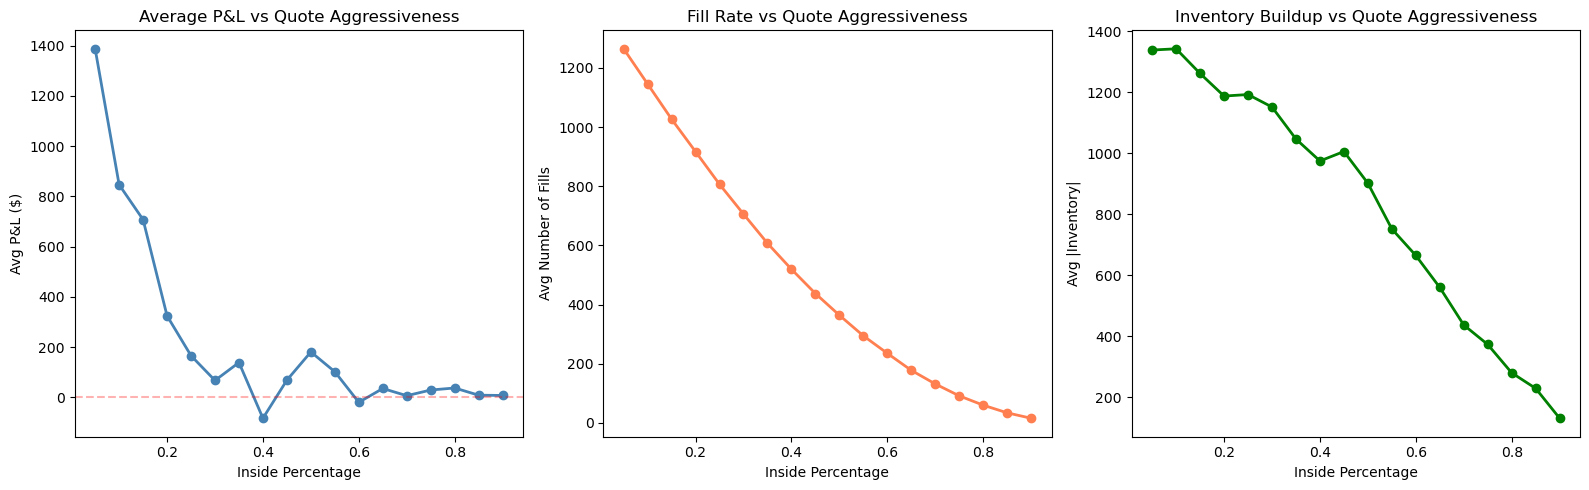

In [20]:
inside_range = np.arange(0.05, 0.95, 0.05)
N_SIMS = 50
N_STEPS = 5000

avg_pnl = []
avg_fills = []
avg_inventory = []

for inside_pct in inside_range:
    pnl_samples = []
    fill_samples = []
    inv_samples = []
    for sim_idx in range(N_SIMS):
        sim = OrderBookSimulator(
            initial_mid=100.0,
            base_spread_bps=5.0,
            volatility=0.02,
            fill_rate=0.15,
            adverse_selection_bps=0.5,
            seed=sim_idx,
        )
        sim.run(n_steps=N_STEPS, inside_pct=float(inside_pct), mm_qty=50)
        pnl_samples.append(sim.mark_to_market_pnl)
        fill_samples.append(len(sim.fills))
        inv_samples.append(abs(sim.inventory))
    avg_pnl.append(np.mean(pnl_samples))
    avg_fills.append(np.mean(fill_samples))
    avg_inventory.append(np.mean(inv_samples))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

ax1.plot(inside_range, avg_pnl, 'o-', color='steelblue', linewidth=2)
ax1.axhline(0, color='red', linestyle='--', alpha=0.3)
ax1.set_xlabel('Inside Percentage')
ax1.set_ylabel('Avg P&L ($)')
ax1.set_title('Average P&L vs Quote Aggressiveness')

ax2.plot(inside_range, avg_fills, 'o-', color='coral', linewidth=2)
ax2.set_xlabel('Inside Percentage')
ax2.set_ylabel('Avg Number of Fills')
ax2.set_title('Fill Rate vs Quote Aggressiveness')

ax3.plot(inside_range, avg_inventory, 'o-', color='green', linewidth=2)
ax3.set_xlabel('Inside Percentage')
ax3.set_ylabel('Avg |Inventory|')
ax3.set_title('Inventory Buildup vs Quote Aggressiveness')

plt.tight_layout()
plt.show()

## 7. Impact of Adverse Selection

Adverse selection is the market maker's biggest enemy. When an informed trader fills our quote, the price tends to move against us.

Let's compare P&L with and without adverse selection.

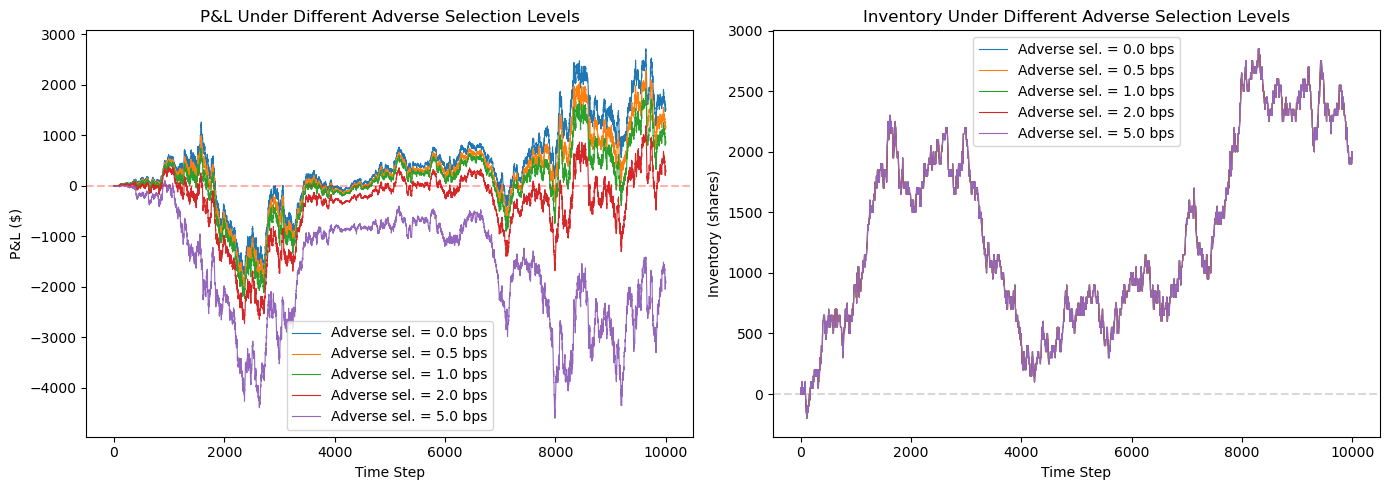

In [22]:
adverse_levels = [0.0, 0.5, 1.0, 2.0, 5.0]
N_STEPS = 10000

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for adv_bps in adverse_levels:
    sim = OrderBookSimulator(
        initial_mid=100.0,
        base_spread_bps=5.0,
        volatility=0.02,
        fill_rate=0.15,
        adverse_selection_bps=adv_bps,
        seed=42,
    )
    sim.run(n_steps=N_STEPS, inside_pct=0.2, mm_qty=50)
    df = sim.get_snapshot_dataframe()
    
    label = f'Adverse sel. = {adv_bps} bps'
    ax1.plot(df['time'], df['pnl'], linewidth=0.8, label=label)
    ax2.plot(df['time'], df['inventory'], linewidth=0.8, label=label)

ax1.axhline(0, color='red', linestyle='--', alpha=0.3)
ax1.set_xlabel('Time Step')
ax1.set_ylabel('P&L ($)')
ax1.set_title('P&L Under Different Adverse Selection Levels')
ax1.legend()

ax2.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Inventory (shares)')
ax2.set_title('Inventory Under Different Adverse Selection Levels')
ax2.legend()

plt.tight_layout()
plt.show()

## 8. Volatility Impact on Market Making

Higher volatility means wider spreads and more price risk. Let's see how the MM performs.

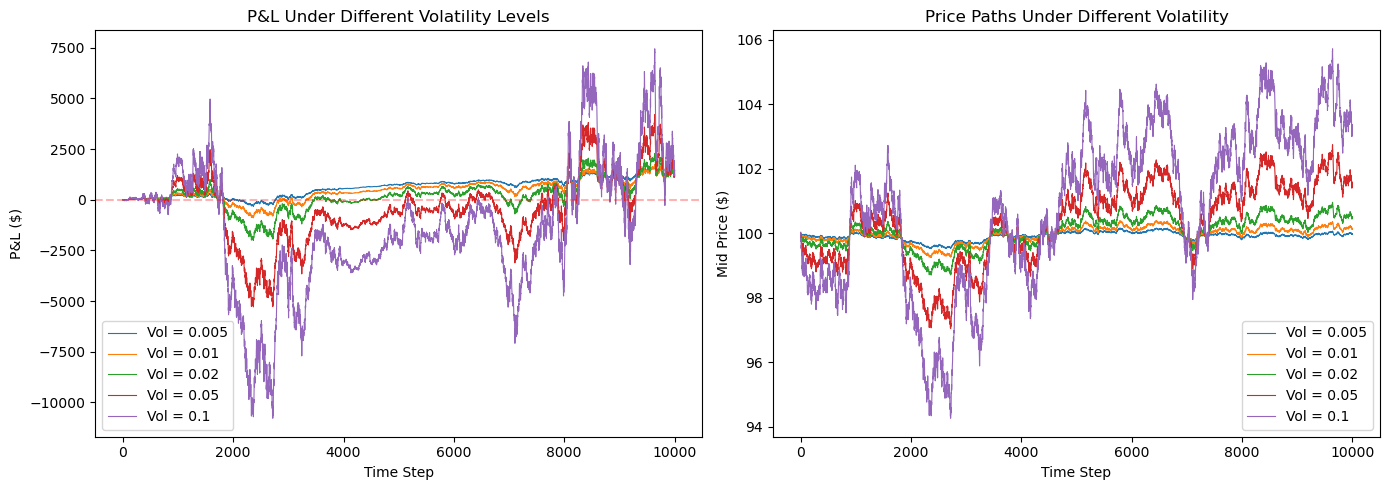

In [24]:
vol_levels = [0.005, 0.01, 0.02, 0.05, 0.1]
N_STEPS = 10000

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for vol in vol_levels:
    sim = OrderBookSimulator(
        initial_mid=100.0,
        base_spread_bps=5.0,
        volatility=vol,
        fill_rate=0.15,
        adverse_selection_bps=0.5,
        seed=42,
    )
    sim.run(n_steps=N_STEPS, inside_pct=0.2, mm_qty=50)
    df = sim.get_snapshot_dataframe()
    
    label = f'Vol = {vol}'
    ax1.plot(df['time'], df['pnl'], linewidth=0.8, label=label)
    ax2.plot(df['time'], df['mid_price'], linewidth=0.8, label=label)

ax1.axhline(0, color='red', linestyle='--', alpha=0.3)
ax1.set_xlabel('Time Step')
ax1.set_ylabel('P&L ($)')
ax1.set_title('P&L Under Different Volatility Levels')
ax1.legend()

ax2.set_xlabel('Time Step')
ax2.set_ylabel('Mid Price ($)')
ax2.set_title('Price Paths Under Different Volatility')
ax2.legend()

plt.tight_layout()
plt.show()

## 9. Monte Carlo: P&L Distribution Across Random Seeds

Run many simulations with different seeds to understand the P&L distribution.

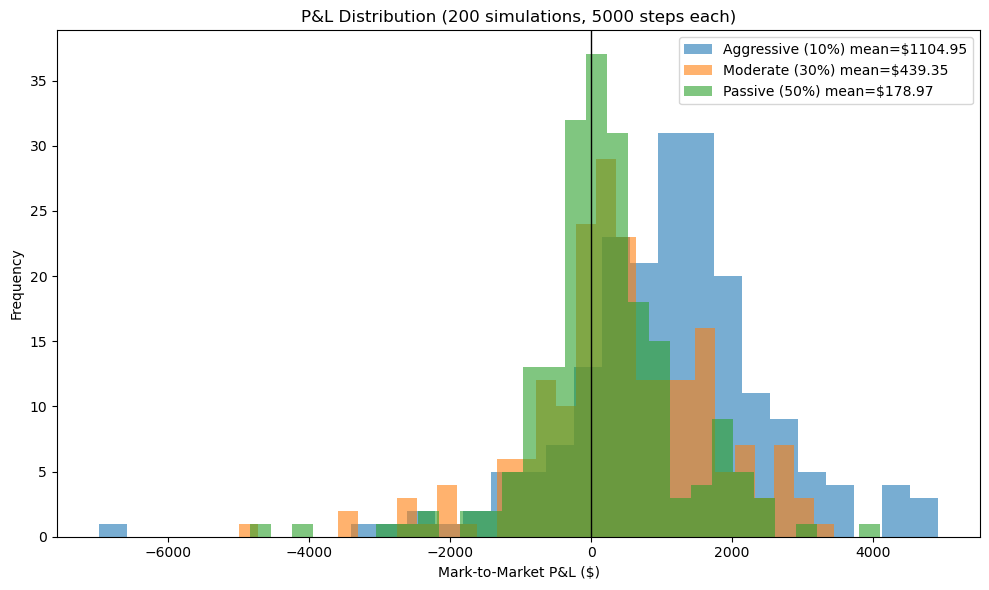


Aggressive (10%): mean=$1104.95, std=$1456.02, Sharpe=0.76
Moderate (30%):   mean=$439.35, std=$1284.39, Sharpe=0.34
Passive (50%):   mean=$178.97, std=$1074.88, Sharpe=0.17


In [25]:
N_SIMS = 200
N_STEPS = 5000

pnl_aggressive = []
pnl_moderate = []
pnl_passive = []

for i in range(N_SIMS):
    sim_a = OrderBookSimulator(initial_mid=100.0, base_spread_bps=5.0, volatility=0.02,
                              fill_rate=0.15, adverse_selection_bps=0.5, seed=i)
    sim_a.run(n_steps=N_STEPS, inside_pct=0.1, mm_qty=50)
    pnl_aggressive.append(sim_a.mark_to_market_pnl)
    
    sim_m = OrderBookSimulator(initial_mid=100.0, base_spread_bps=5.0, volatility=0.02,
                              fill_rate=0.15, adverse_selection_bps=0.5, seed=i)
    sim_m.run(n_steps=N_STEPS, inside_pct=0.3, mm_qty=50)
    pnl_moderate.append(sim_m.mark_to_market_pnl)
    
    sim_p = OrderBookSimulator(initial_mid=100.0, base_spread_bps=5.0, volatility=0.02,
                              fill_rate=0.15, adverse_selection_bps=0.5, seed=i)
    sim_p.run(n_steps=N_STEPS, inside_pct=0.5, mm_qty=50)
    pnl_passive.append(sim_p.mark_to_market_pnl)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(pnl_aggressive, bins=30, alpha=0.6, label=f'Aggressive (10%) mean=${np.mean(pnl_aggressive):.2f}')
ax.hist(pnl_moderate, bins=30, alpha=0.6, label=f'Moderate (30%) mean=${np.mean(pnl_moderate):.2f}')
ax.hist(pnl_passive, bins=30, alpha=0.6, label=f'Passive (50%) mean=${np.mean(pnl_passive):.2f}')
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Mark-to-Market P&L ($)')
ax.set_ylabel('Frequency')
ax.set_title(f'P&L Distribution ({N_SIMS} simulations, {N_STEPS} steps each)')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nAggressive (10%): mean=${np.mean(pnl_aggressive):.2f}, std=${np.std(pnl_aggressive):.2f}, "
      f"Sharpe={np.mean(pnl_aggressive)/np.std(pnl_aggressive):.2f}")
print(f"Moderate (30%):   mean=${np.mean(pnl_moderate):.2f}, std=${np.std(pnl_moderate):.2f}, "
      f"Sharpe={np.mean(pnl_moderate)/np.std(pnl_moderate):.2f}")
print(f"Passive (50%):   mean=${np.mean(pnl_passive):.2f}, std=${np.std(pnl_passive):.2f}, "
      f"Sharpe={np.mean(pnl_passive)/np.std(pnl_passive):.2f}")

## 10. Fill Slippage Distribution

How much slippage does the MM experience on fills? (Fill price vs quote price)

In [ ]:
sim = OrderBookSimulator(
    initial_mid=100.0, base_spread_bps=5.0, volatility=0.02,
    fill_rate=0.15, adverse_selection_bps=0.5, seed=42,
)
sim.run(n_steps=10000, inside_pct=0.2, mm_qty=50)
fills_df = sim.get_fills_dataframe()

if len(fills_df) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    buy_slips = fills_df[fills_df['side'] == 'buy']['slippage']
    sell_slips = fills_df[fills_df['side'] == 'sell']['slippage']
    
    ax1.hist(buy_slips, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
    ax1.axvline(buy_slips.mean(), color='red', linestyle='--', label=f'Mean: ${buy_slips.mean():.4f}')
    ax1.set_xlabel('Slippage ($)')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Buy Fill Slippage (adverse: pay more)')
    ax1.legend()
    
    ax2.hist(sell_slips, bins=30, color='coral', alpha=0.7, edgecolor='white')
    ax2.axvline(sell_slips.mean(), color='red', linestyle='--', label=f'Mean: ${sell_slips.mean():.4f}')
    ax2.set_xlabel('Slippage ($)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Sell Fill Slippage (adverse: receive less)')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

---

## Summary

| Parameter | Effect on MM |
|-----------|-------------|
| **inside_pct** (lower) | More fills (queue priority near edge), less profit per fill, more adverse selection |
| **volatility** (higher) | Wilder price swings, wider effective spread, more inventory risk |
| **adverse_selection_bps** (higher) | Price moves against MM after fills, erodes P&L |
| **fill_rate** (higher) | More fills per step, higher turnover |
| **base_spread_bps** (wider) | More room to profit per round-trip |

### Key Takeaways

1. **The spread is the MM's revenue**. Profit per round-trip is roughly the spread × (1 - inside_pct) — lower inside_pct means narrower capture.
2. **Adverse selection is the MM's cost**. Informed traders fill aggressive quotes, then price moves against us.
3. **Optimal inside_pct depends on market conditions**. More volatile markets favor passive quotes (wider capture per fill); less volatile markets favor aggressive quotes (more fills).
4. **Inventory management matters**. Unbalanced fills lead to inventory buildup and directional risk.